## Project 3: Fake Image Classifier

This project aims to classify images as fake or real using a Convolutional Neural Network (CNN).<br>
The workflow includes data preparation, model training, evaluation, and explainability Grad-CAM.

## Unzip The folder of dataset

In [12]:
import zipfile
import os

zip_path = "./data.zip"
extract_path = "./dataset"

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped.")


Dataset unzipped.


## Imports & Setup

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import seaborn as sns
print('Imported')

Imported


Print the version pf Tensorflow

In [14]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Data Loading and Augmentation

The images are resized to 32×32 pixels to reduce computational complexity.<br>
The dataset is split into training and validation sets using an 80/20 ratio.<br>
<br>
Data augmentation is applied only to the training data to improve generalization,<br>
while validation data is kept unchanged to ensure fair evaluation.<br>

In [15]:
img_size = (32, 32)
batch_size = 32
val_split = 0.2

dataset_path = "./dataset"


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=val_split
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
)


train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    shuffle=True
)


val_generator = val_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    shuffle=False
)


Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


## Visualizing Sample Images

Sample images from the dataset are visualized to verify correct data loading.<br>
This helps confirm that images and labels are correctly assigned to fake and real classes.<br>

In [16]:
def plot_images(generator, title):
    images, labels = next(generator)

    plt.figure(figsize=(6, 6))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        plt.title("Fake" if labels[i] == 0 else "Real")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

Images Before Augmentation<br>

This visualization shows sample images before applying any data augmentation.<br>
It provides a reference to compare how augmentation changes the appearance of the images.<br>


Found 100000 images belonging to 2 classes.


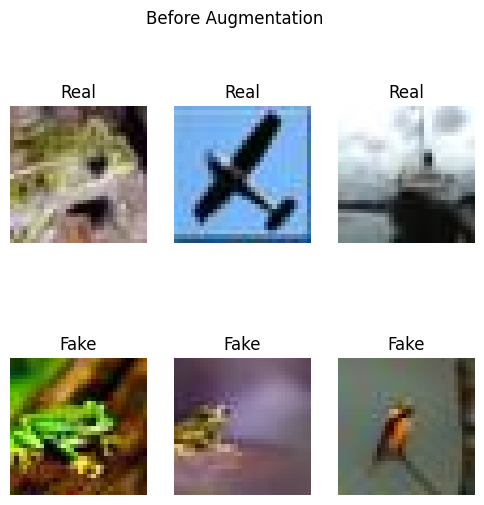

In [17]:
raw_datagenerator = ImageDataGenerator(rescale=1./255)

raw_generator = raw_datagenerator.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=img_size,
    batch_size=6,
    class_mode="binary",
    shuffle=True
)

plot_images(raw_generator, "Before Augmentation")


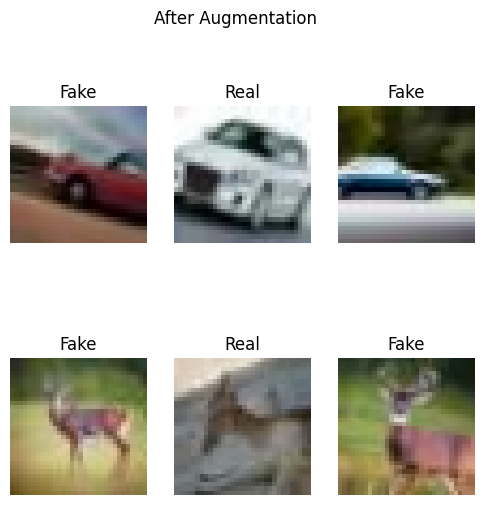

In [18]:
plot_images(train_generator, "After Augmentation")

## Model Architecture
A compact CNN with fewer than 100,000 parameters is used as required.<br>
The model consists of convolutional layers for feature extraction and a dense layer for classification.<br>
Dropout is added to reduce overfitting.<br>

In [19]:
model = models.Sequential([
    # Input layer
    layers.Conv2D(16, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    # Output layer (binary classification)
    layers.Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\drshn\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,097 (156.63 KB)

 Trainable params: 40,097 (156.63 KB)

 Non-trainable params: 0 (0.00 B)

## Saving the Best Model Weights

ModelCheckpoint is used to save the model weights with the lowest validation loss.<br>
This ensures that the best-performing model is retained, even if later epochs perform worse.<br>
<br>

In [20]:
best_weights = "./dataset/best_model.weights.h5"

checkpoint = ModelCheckpoint(
    filepath=best_weights,
    monitor="val_loss",       # monitor validation loss
    save_best_only=True,      # save only when val_loss improves
    save_weights_only=True,   # save only weights
    verbose=1
)

## Early Stopping to Prevent Overfitting

EarlyStopping is used to stop training when the validation loss no longer improves.<br>
This helps prevent overfitting and avoids unnecessary training epochs by restoring the best model weights.<br>


In [21]:
earlystop = EarlyStopping(
    monitor="val_loss",        # monitor validation loss
    patience=3,                # stop training if val_loss does not improve for 3 epochs
    restore_best_weights=True, # save only best weights
    verbose=1                  # print a message when early stopping is triggered
)

## Model Training

The model is trained for a maximum of 15 epochs using the training data.<br>
Validation data is used to monitor performance during training.<br>

EarlyStopping and ModelCheckpoint callbacks are applied to improve training stability and ensure that the best-performing model is retained.

In [22]:
ep = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=ep,
    callbacks=[checkpoint,earlystop]
)


Epoch 1/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.7376 - loss: 0.5165
Epoch 1: val_loss improved from None to 0.45595, saving model to ./dataset/best_model.weights.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 829s 331ms/step - accuracy: 0.7927 - loss: 0.4436 - val_accuracy: 0.7935 - val_loss: 0.4559
Epoch 2/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8589 - loss: 0.3337
Epoch 2: val_loss did not improve from 0.45595
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 106s 42ms/step - accuracy: 0.8637 - loss: 0.3228 - val_accuracy: 0.7980 - val_loss: 0.4874
Epoch 3/15
2499/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8771 - loss: 0.2954
Epoch 3: val_loss did not improve from 0.45595
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 103s 41ms/step - accuracy: 0.8798 - loss: 0.2902 - val_accuracy: 0.7994 - val_loss: 0.4969
Epoch 4/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8864 - loss: 0.2760
Epoch 4: val_loss did not improve from 0.45595
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 100s 40

## Saving the Final Model

After training, the best model weights are loaded and saved to Google Drive.<br>
Both the complete model and the model weights are stored for future use.


In [23]:
saved = "./dataset"

model.load_weights("./dataset/best_model.weights.h5")
model.save(os.path.join(saved, "pml3_image_classifier_model.h5"))

print("Model and weights saved.")

Model and weights saved.


## Training and Validation Loss Curves

The training and validation loss curves are plotted to analyze the learning behavior of the model.<br>
An increase in validation loss indicates overfitting, which helps justify the use of EarlyStopping.<br>

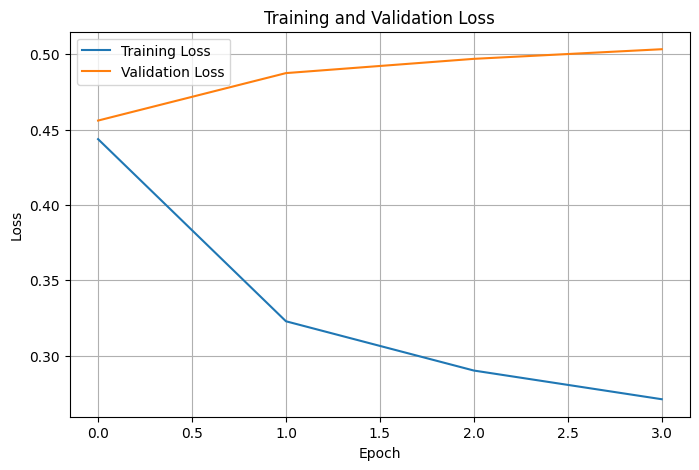

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

## PCA Visualization of Learned Features

Principal Component Analysis (PCA) is applied to the features learned by the CNN.<br>
The high-dimensional feature space is reduced to two dimensions to visualize how fake and real images are separated.<br>

This helps understand whether the model has learned meaningful and discriminative representations.<br>

625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step


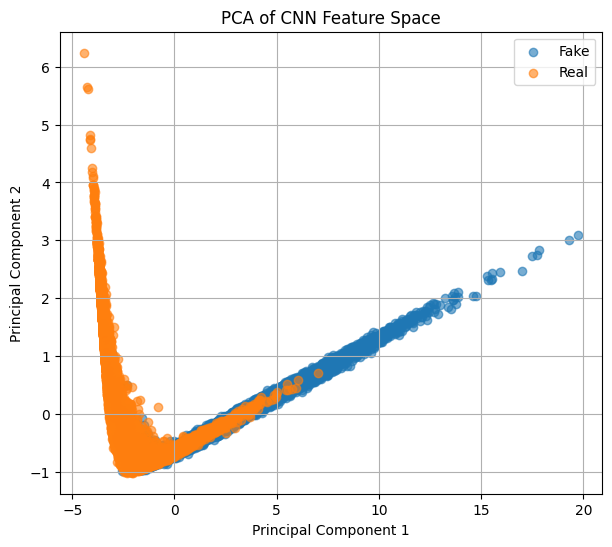

In [25]:
# Feature extractor: take output before final classification layer

model.build((None, 32, 32, 3))

feature_extractor = Model(
    inputs=model.inputs[0],
    outputs=model.layers[-3].output
)

# Extract features from validation data
features = feature_extractor.predict(val_generator)
labels = val_generator.classes

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

# Plot PCA result
plt.figure(figsize=(7, 6))

plt.scatter(
    features_2d[labels == 0, 0],
    features_2d[labels == 0, 1],
    label="Fake",
    alpha=0.6
)

plt.scatter(
    features_2d[labels == 1, 0],
    features_2d[labels == 1, 1],
    label="Real",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of CNN Feature Space")
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation on Test Data

The trained model is evaluated on the test dataset to assess its generalization performance.<br>
Accuracy, precision, recall, and a confusion matrix are used to analyze classification results.

The confusion matrix helps identify correct predictions and common misclassification patterns.

Found 20000 images belonging to 2 classes.
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 225ms/step
Classification Report:

              precision    recall  f1-score   support

        Fake       0.72      0.98      0.83     10000
        Real       0.96      0.61      0.75     10000

    accuracy                           0.80     20000
   macro avg       0.84      0.80      0.79     20000
weighted avg       0.84      0.80      0.79     20000



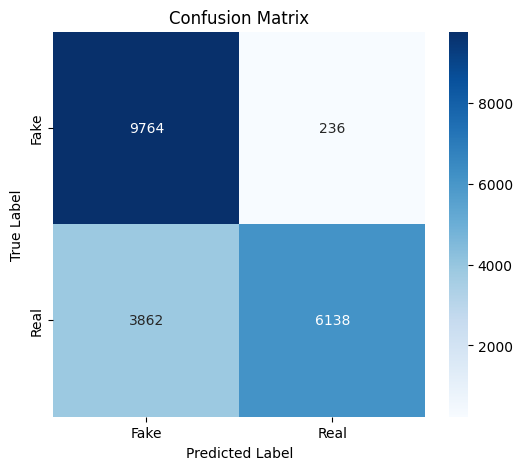

In [26]:
# Load best weights
model.load_weights("./dataset/best_model.weights.h5")

# Test data generator (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    os.path.join("./dataset", "test"),
    target_size=(32, 32),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

# Predict probabilities
y_pred_prob = model.predict(test_generator)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# True labels
y_true = test_generator.classes

# Classification Report
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Fake", "Real"]
))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Model Explanation using Grad-CAM

Grad-CAM is used to explain the model's predictions by highlighting the image regions that most influence the classification decision.

The method visualizes important areas for both fake and real images, helping to verify whether the model focuses on meaningful visual features rather than irrelevant regions.

Model compiled and built. Metrics are ready.
Using layer: conv2d_5


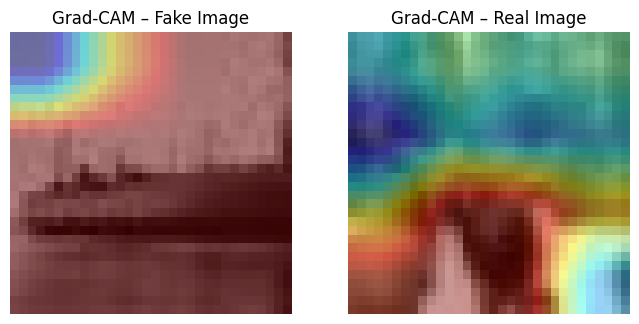

In [31]:
# Load trained model
model = tf.keras.models.load_model(
    "./dataset/pml3_image_classifier_model.h5"
)

# Build compiled metrics by compiling and running a dummy evaluation
# This ensures model.output and other attributes are properly initialized
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Build the model by calling it with a dummy input (this initializes model.output)
dummy_input = tf.zeros((1, 32, 32, 3))
_ = model(dummy_input)

# Now the compiled metrics are built and model.output is available
print("Model compiled and built. Metrics are ready.")

# Find the last convolutional layer automatically
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

if last_conv_layer is None:
    raise ValueError("No convolutional layer found in the model.")

last_conv_layer_name = last_conv_layer.name
print(f"Using layer: {last_conv_layer_name}")


# Grad-CAM function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create input tensor
    model_input = tf.keras.Input(shape=(32, 32, 3))
    
    # Trace through model layers to build the graph
    x = model_input
    conv_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x
    
    # Final output
    final_output = x
    
    # Create a model that outputs both conv layer and final prediction
    grad_model = tf.keras.models.Model(
        inputs=model_input,
        outputs=[conv_output, final_output]
    )
    
    # Use GradientTape to compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        # For binary classification, use the prediction score directly
        loss = predictions[0]
    
    # Compute gradients of the loss with respect to the conv layer output
    grads = tape.gradient(loss, conv_outputs)
    
    if grads is None:
        raise RuntimeError("Gradients are None. Check Grad-CAM setup.")
    
    # Pool the gradients over spatial dimensions (average pooling)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply each channel by its corresponding pooled gradient
    heatmap = conv_outputs[0] * pooled_grads
    
    # Sum across channels to get 2D heatmap
    heatmap = tf.reduce_sum(heatmap, axis=-1)
    
    # ReLU to keep only positive contributions
    heatmap = tf.maximum(heatmap, 0)
    
    # Normalize
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val
    
    return heatmap.numpy()


# Load image function
def load_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(32, 32))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img, img_array


# Image paths
fake_img_path = "./dataset/test/FAKE/100 (9).jpg"
real_img_path = "./dataset/test/REAL/0001 (5).jpg"


# Generate Grad-CAM
fake_img, fake_array = load_image(fake_img_path)
fake_heatmap = make_gradcam_heatmap(fake_array, model, last_conv_layer_name)

real_img, real_array = load_image(real_img_path)
real_heatmap = make_gradcam_heatmap(real_array, model, last_conv_layer_name)


# Overlay heatmap
def overlay_heatmap(img, heatmap):
    heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    img = np.array(img)
    return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)


# Plot results
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(overlay_heatmap(fake_img, fake_heatmap))
plt.title("Grad-CAM – Fake Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay_heatmap(real_img, real_heatmap))
plt.title("Grad-CAM – Real Image")
plt.axis("off")

plt.show()